✅ Accuracy: 0.5

📊 Confusion Matrix:
 [[3 1]
 [2 0]]

📋 Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.75      0.67         4
           1       0.00      0.00      0.00         2

    accuracy                           0.50         6
   macro avg       0.30      0.38      0.33         6
weighted avg       0.40      0.50      0.44         6



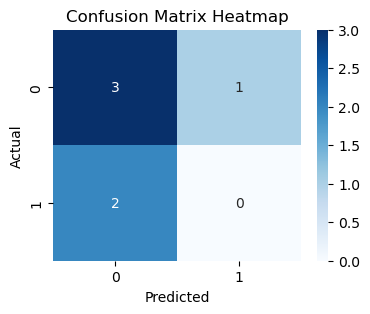

C:\Users\KIIT\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


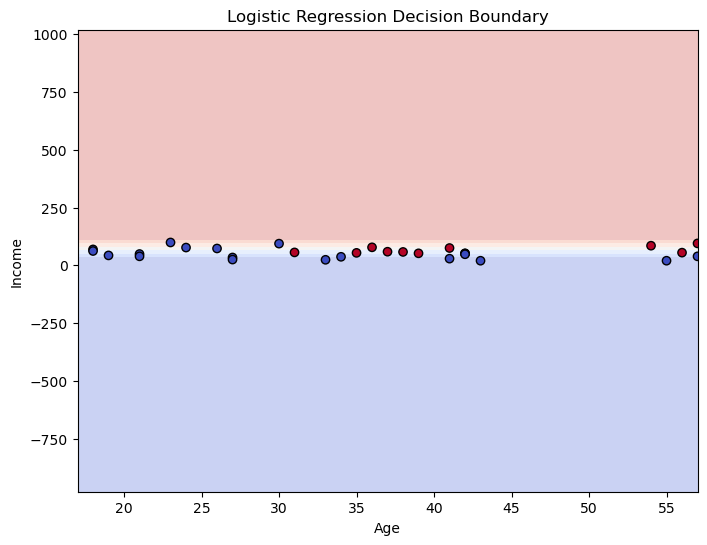

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Step 1: Load dataset (replace with your actual file name)
df = pd.read_csv('C:\\Users\\KIIT\\Python\\AD_LAB\\logistic_regression_dataset.csv')  # Make sure this file is in your project folder

# Step 2: Features and target
X = df[['Age', 'Income']]
y = df['Buy']

# Step 3: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Step 4: Train the logistic regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Step 5: Make predictions
y_pred = model.predict(X_test)

# Step 6: Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("✅ Accuracy:", accuracy)
print("\n📊 Confusion Matrix:\n", cm)
print("\n📋 Classification Report:\n", report)

# Step 7: Confusion matrix heatmap
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()

# Step 8: Decision boundary plot (for 2 features)
x_min, x_max = X['Age'].min() - 1, X['Age'].max() + 1
y_min, y_max = X['Income'].min() - 1000, X['Income'].max() + 1000

xx, yy = np.meshgrid(np.arange(x_min, x_max, 1),
                     np.arange(y_min, y_max, 100))

grid = np.c_[xx.ravel(), yy.ravel()]
Z = model.predict(grid)
Z = Z.reshape(xx.shape)

# Final plot
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X['Age'], X['Income'], c=y, cmap='coolwarm', edgecolor='k')
plt.xlabel('Age')
plt.ylabel('Income')
plt.title('Logistic Regression Decision Boundary')
plt.show()
